## Xgboost vs RandomForest

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [177]:
df = pd.read_csv('../data/processed/feature_engineered_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (95094, 42)


,payment_count,total_items,total_freight_value,estimated_delivery_days,avg_product_price,avg_product_freight,avg_product_review,avg_product_weight,main_category,total_products_in_order,...,state_RJ,state_RN,state_RO,state_RR,state_RS,state_SC,state_SE,state_SP,state_TO,is_late
0,1,1,13.29,15.625671,59.233333,22.033333,4.444444,650.0,27,1,...,1,0,0,0,0,0,0,0,0,0
1,1,1,19.93,18.546458,239.900000,19.930000,4.000000,30000.0,64,1,...,0,0,0,0,0,0,0,1,0,0
2,1,1,17.87,21.393391,199.000000,18.606667,4.333333,3050.0,55,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,12.79,11.582928,12.990000,12.790000,4.000000,200.0,63,1,...,0,0,0,0,0,0,0,1,0,0
4,1,1,18.14,40.418160,202.400000,27.052500,3.833333,3750.0,41,1,...,0,0,0,0,0,0,0,1,0,0


In [178]:
target = 'is_late'
X = df.drop(columns=[target])
y = df[target]

print(f"Target distribution:\n{y.value_counts()}")


Target distribution:
is_late
0    87302
1     7792
Name: count, dtype: int64


In [179]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (76075, 41)
Test size: (19019, 41)


In [180]:
# Calculate scale_pos_weight for imbalance 
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 11.20


# Xgboost

In [181]:
model = XGBClassifier(n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False)

In [182]:
model.fit(X_train, y_train)

c:\Users\R\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:01:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [183]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions done")

Predictions done


In [184]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Late']))

Classification Report:
              precision    recall  f1-score   support

     On Time       0.97      0.75      0.84     17461
        Late       0.20      0.72      0.32      1558

    accuracy                           0.74     19019
   macro avg       0.58      0.73      0.58     19019
weighted avg       0.90      0.74      0.80     19019



In [185]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.8079


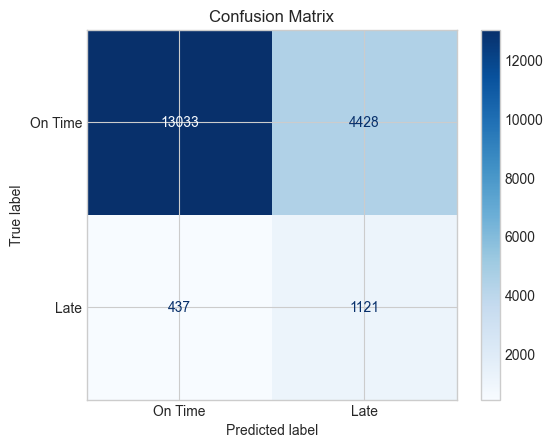

In [186]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Late'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

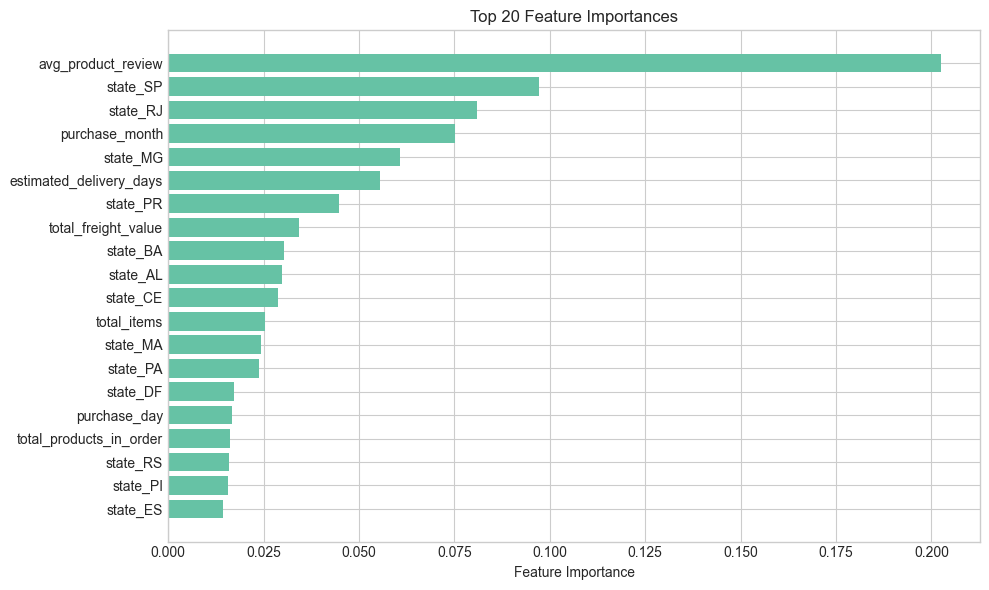

In [187]:
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feature_names = X.columns
    indices = np.argsort(importances)[::-1][:20]
    
    plt.figure(figsize=(10,6))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()
else:
    print("Model has no feature_importances_ attribute")

In [188]:
# Get predictions
y_pred = model.predict(X_test)

# Build confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Total actual orders in test set
total_actual_on_time = tn + fp   # actually not late
total_actual_late   = fn + tp   # actually late



In [ ]:
# Percentages (out of actual class)
tn_rate = tn / total_actual_on_time * 100   # % of on‑time orders correctly predicted
fp_rate = fp / total_actual_on_time * 100   # % of on‑time orders wrongly said would be late
fn_rate = fn / total_actual_late * 100      # % of late orders missed
tp_rate = tp / total_actual_late * 100      # % of late orders caught

print("===== Confusion Matrix Explained =====")
print()
print(" Out of all orders that were ACTUALLY ON TIME:")
print(f"   ✅ {tn_rate:.1f}% were correctly predicted as ON TIME (we were right).")
print(f"   ❌ {fp_rate:.1f}% were WRONGLY predicted as LATE (false alarm).")
print()
print(" Out of all orders that were ACTUALLY LATE:")
print(f"   ✅ {tp_rate:.1f}% were correctly predicted as LATE (we caught the delay).")
print(f"   ❌ {fn_rate:.1f}% were WRONGLY predicted as ON TIME (we missed the delay).")


===== Confusion Matrix Explained =====

 Out of all orders that were ACTUALLY ON TIME:
   ✅ 74.6% were correctly predicted as ON TIME (we were right).
   ❌ 25.4% were WRONGLY predicted as LATE (false alarm).

 Out of all orders that were ACTUALLY LATE:
   ✅ 72.0% were correctly predicted as LATE (we caught the delay).
   ❌ 28.0% were WRONGLY predicted as ON TIME (we missed the delay).


# Random Forest

In [202]:
from sklearn.ensemble import RandomForestClassifier    

In [203]:
rd_model = RandomForestClassifier(
        max_depth=3,
        max_leaf_nodes=3,
        n_estimators=150,
        random_state=42,
        class_weight='balanced'
)

In [204]:
rd_model.fit(X_train, y_train)  

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [205]:
ypred_rd = rd_model.predict(X_test)

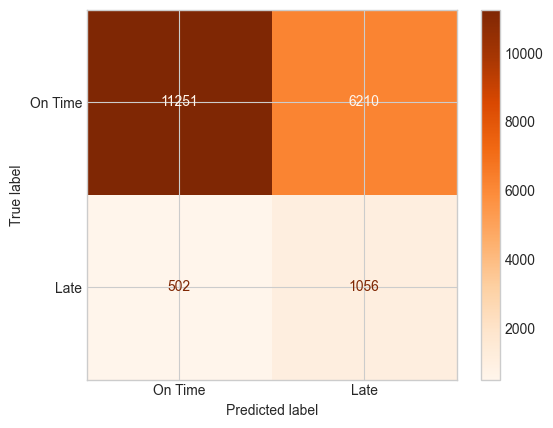

In [206]:
confusion_matrix_rd = confusion_matrix(y_test, ypred_rd)
disp_rd = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_rd, display_labels=['On Time', 'Late'])
disp_rd.plot(cmap='Oranges', values_format='d')

In [207]:
# Build confusion matrix
cm = confusion_matrix(y_test, ypred_rd)
tn, fp, fn, tp = cm.ravel()

# Total actual orders in test set
total_actual_on_time = tn + fp   # actually not late
total_actual_late   = fn + tp   # actually late
# Percentages (out of actual class)
tn_rate = tn / total_actual_on_time * 100   # % of on‑time orders correctly predicted
fp_rate = fp / total_actual_on_time * 100   # % of on‑time orders wrongly said would be late
fn_rate = fn / total_actual_late * 100      # % of late orders missed
tp_rate = tp / total_actual_late * 100      # % of late orders caught

print("===== Confusion Matrix Explained =====")
print()
print(" Out of all orders that were ACTUALLY ON TIME:")
print(f"   ✅ {tn_rate:.1f}% were correctly predicted as ON TIME (we were right).")
print(f"   ❌ {fp_rate:.1f}% were WRONGLY predicted as LATE (false alarm).")
print()
print(" Out of all orders that were ACTUALLY LATE:")
print(f"   ✅ {tp_rate:.1f}% were correctly predicted as LATE (we caught the delay).")
print(f"   ❌ {fn_rate:.1f}% were WRONGLY predicted as ON TIME (we missed the delay).")


===== Confusion Matrix Explained =====

 Out of all orders that were ACTUALLY ON TIME:
   ✅ 64.4% were correctly predicted as ON TIME (we were right).
   ❌ 35.6% were WRONGLY predicted as LATE (false alarm).

 Out of all orders that were ACTUALLY LATE:
   ✅ 67.8% were correctly predicted as LATE (we caught the delay).
   ❌ 32.2% were WRONGLY predicted as ON TIME (we missed the delay).
